# Exercise 4 - Chemostat: Yeast Biomass Production

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


**Question a)**
In a chemostat at steady state, the specific growth rate $\mu$ equals the dilution rate $D$:

$$D = \mu = \mu_{\max} \frac{S}{K_s + S}$$

where:
- $\mu_{\max}$ is the maximum specific growth rate (h⁻¹)
- $K_s$ is the saturation (Monod) constant (g/L)
- $S$ is the steady-state substrate concentration (g/L)

This equation is true because at steady state, cell growth exactly compensates for dilution losses.

Taking the reciprocal of the Monod equation:

$$\frac{1}{D} = \frac{K_s}{\mu_{\max}} \cdot \frac{1}{S} + \frac{1}{\mu_{\max}}$$

Plotting $1/D$ versus $1/S$ yields a straight line with:
- slope $= K_s / \mu_{\max}$
- y-intercept $= 1 / \mu_{\max}$
- x-intercept $= -1 / K_s$

The highest dilution rate ($D = 0.84$ h⁻¹) is excluded from the fit because at this operating point, cell concentration drops sharply and residual substrate jumps, indicating washout. This means that cells can no longer grow fast enough to keep up with dilution, so they are being removed from the reactor faster than they reproduce. Including these points would therefore violate the steady-state assumption.

  Monod parameter estimation (part a)
  Slope     (Ks / µmax) = 0.2386  h·g/L
  Intercept (1 / µmax)  = 0.4351  h
  µmax                  = 2.2982  h⁻¹
  Ks                    = 0.5482  g/L


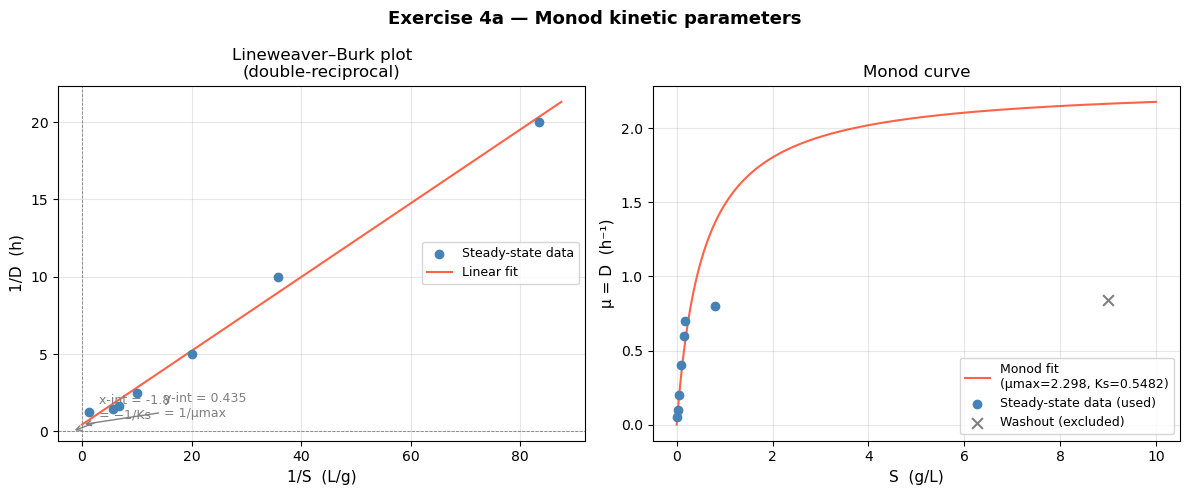

In [4]:
D = np.array([0.05, 0.10, 0.20, 0.40, 0.60, 0.70, 0.80, 0.84])  
X = np.array([3.2,  3.7,  4.0,  4.4,  4.75, 4.9,  4.5,  0.5])   
S = np.array([0.012,0.028,0.050,0.100,0.150,0.176,0.800,9.000])  
S0 = 10.0  

mask   = D <= 0.80
D_fit  = D[mask]
S_fit  = S[mask]

inv_D = 1.0 / D_fit
inv_S = 1.0 / S_fit

slope, intercept = np.polyfit(inv_S, inv_D, 1)

mu_max = 1.0 / intercept       
Ks     = slope * mu_max          

print("=" * 45)
print("  Monod parameter estimation (part a)")
print("=" * 45)
print(f"  Slope     (Ks / µmax) = {slope:.4f}  h·g/L")
print(f"  Intercept (1 / µmax)  = {intercept:.4f}  h")
print(f"  µmax                  = {mu_max:.4f}  h⁻¹")
print(f"  Ks                    = {Ks:.4f}  g/L")
print("=" * 45)

inv_S_line = np.linspace(0, max(inv_S) * 1.05, 300)
inv_D_line = slope * inv_S_line + intercept

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
ax1.scatter(inv_S, inv_D, color="steelblue", zorder=5, label="Steady-state data")
ax1.plot(inv_S_line, inv_D_line, color="tomato", label="Linear fit")

ax1.axhline(0, color="grey", linewidth=0.6, linestyle="--")
ax1.axvline(0, color="grey", linewidth=0.6, linestyle="--")

ax1.annotate(f"y-int = {intercept:.3f}\n= 1/µmax",
             xy=(0, intercept), xytext=(15, intercept + 0.5),
             arrowprops=dict(arrowstyle="->", color="grey"),
             fontsize=9, color="grey")
x_int = -intercept / slope          # x-intercept = −1/Ks
ax1.annotate(f"x-int = {x_int:.1f}\n= −1/Ks",
             xy=(x_int, 0), xytext=(x_int + 5, 0.8),
             arrowprops=dict(arrowstyle="->", color="grey"),
             fontsize=9, color="grey")

ax1.set_xlabel("1/S  (L/g)", fontsize=11)
ax1.set_ylabel("1/D  (h)", fontsize=11)
ax1.set_title("Lineweaver–Burk plot\n(double-reciprocal)", fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
S_range = np.linspace(0, S0, 500)
mu_monod = mu_max * S_range / (Ks + S_range)

ax2.plot(S_range, mu_monod, color="tomato", label=f"Monod fit\n(µmax={mu_max:.3f}, Ks={Ks:.4f})")
ax2.scatter(S_fit, D_fit, color="steelblue", zorder=5, label="Steady-state data (used)")
ax2.scatter(S[~mask], D[~mask], color="grey", marker="x", zorder=5, s=60, label="Washout (excluded)")

ax2.set_xlabel("S  (g/L)", fontsize=11)
ax2.set_ylabel("µ = D  (h⁻¹)", fontsize=11)
ax2.set_title("Monod curve", fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle("Exercise 4a — Monod kinetic parameters", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("ex4a_monod.png", dpi=150, bbox_inches="tight")
plt.show()

| Parameter | Value | Units |
|-----------|-------|-------|
| $\mu_{\max}$ | 2.2982 | h⁻¹ |
| $K_s$ | 0.5482 | g/L |

The Lineweaver–Burk linearisation yields $\mu_{\max} = 2.2982\ \text{h}^{-1}$ and $K_s = 0.5482\ \text{g/L}$. The $\mu_{\max}$ value exceeds typical aerobic literature values for yeast growth, and $K_s$ is higher than commonly reported. This is likely attributable to the double-reciprocal transformation: taking $1/S$ compresses the high-substrate points and stretches the low-substrate points, giving disproportionate weight to the least reliable measurements (low $S$, high $1/S$). The fit is therefore dominated by the point at $S = 0.012$ g/L, which pulls the line and inflates both parameters.
 
To obtain more reliable estimates, the Monod equation is fitted directly to the $(S, D)$ data using non-linear least squares regression.
Instead of transforming the data, `scipy.optimize.curve_fit` minimises the sum of squared residuals directly in the original data space:
 
$$\min_{\mu_{\max},\, K_s} \sum_i \left( D_i - \mu_{\max} \frac{S_i}{K_s + S_i} \right)^2$$
 
This avoids any distortion introduced by the double-reciprocal transformation and gives equal statistical weight to all data points. 
 

Parameter          Lineweaver-Burk         Non-linear
-------------------------------------------------------
µmax (h⁻¹)                  2.2982             0.9975
Ks (g/L)                    0.5482             0.1288
R²                          0.3520             0.9304

Non-linear 1σ uncertainties:  µmax ± 0.1332 h⁻¹  |  Ks ± 0.0433 g/L


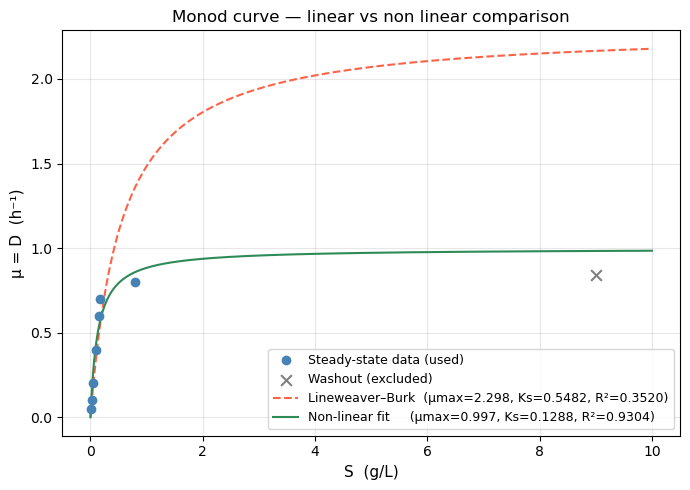

In [ ]:
from scipy.optimize import curve_fit

def monod(S, mu_max, Ks):
    return mu_max * S / (Ks + S)

popt, pcov   = curve_fit(monod, S_fit, D_fit, p0=[1.0, 0.1], bounds=(0, np.inf))
mu_max_nl, Ks_nl = popt
perr             = np.sqrt(np.diag(pcov))   # 1-sigma uncertainties

def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

R2_lb = r_squared(D_fit, monod(S_fit, mu_max, Ks))       # mu_max, Ks from LB cell
R2_nl = r_squared(D_fit, monod(S_fit, mu_max_nl, Ks_nl))


print("=" * 55)
print(f"{'Parameter':<15} {'Lineweaver-Burk':>18} {'Non-linear':>18}")
print("-" * 55)
print(f"{'µmax (h⁻¹)':<15} {mu_max:>18.4f} {mu_max_nl:>18.4f}")
print(f"{'Ks (g/L)':<15} {Ks:>18.4f} {Ks_nl:>18.4f}")
print(f"{'R²':<15} {R2_lb:>18.4f} {R2_nl:>18.4f}")
print("=" * 55)
print(f"\nNon-linear 1σ uncertainties:  µmax ± {perr[0]:.4f} h⁻¹  |  Ks ± {perr[1]:.4f} g/L")


S_range = np.linspace(0, S0, 500)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(S_fit,    D_fit,    color="steelblue", zorder=5, label="Steady-state data (used)")
ax.scatter(S[~mask], D[~mask], color="grey", marker="x", s=60, zorder=5, label="Washout (excluded)")
ax.plot(S_range, monod(S_range, mu_max, Ks), color="tomato", linestyle="--",
        label=f"Lineweaver–Burk  (µmax={mu_max:.3f}, Ks={Ks:.4f}, R²={R2_lb:.4f})")
ax.plot(S_range, monod(S_range, mu_max_nl, Ks_nl), color="seagreen",
        label=f"Non-linear fit     (µmax={mu_max_nl:.3f}, Ks={Ks_nl:.4f}, R²={R2_nl:.4f})")

ax.set_xlabel("S  (g/L)", fontsize=11)
ax.set_ylabel("µ = D  (h⁻¹)", fontsize=11)
ax.set_title("Monod curve — linear vs non linear comparison", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ex4a_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

We get the following results now:

| Parameter | Lineweaver–Burk | Non-linear regression |
|-----------|:--------------:|:--------------------:|
| $\mu_{\max}$ (h⁻¹) | 2.2982 | 0.9975 |
| $K_s$ (g/L) | 0.5482 | 0.1288 |
| $R^2$ | 0.3520 | 0.9304 |

The non-linear regression yields a higher $R^2$ value and parameters that are more consistent with literature values for aerobic yeast growth, confirming that the Lineweaver–Burk overestimation was an result of the double-reciprocal transformation rather than a true biological feature of the data.

The $1\sigma$ uncertainties from the covariance matrix of `curve_fit` further quantify the reliability of the non-linear estimates. However, for consistency with the methodology presented in lecture 2 of the course, the Lineweaver–Burk estimates were used in the subsequent analysis.

**Question b)**

At steady state in a chemostat, the substrate consumed goes towards two things: producing new biomass and covering the maintenance energy requirements of existing cells:
 
$$D(S_{in} - S) = \frac{\mu \cdot X}{Y_{X/S}} + m \cdot X$$
 
where:
- $Y_{X/S}$ is the true biomass yield on substrate (g biomass / g substrate)
- $m$ is the maintenance energy coefficient (g substrate / g biomass / h)
- $S_{in} - S$ is the substrate consumed (g/L)

This is also known as the Herbirt Pirt equation.
 
Since $D = \mu$ at steady state, dividing both sides by $X$ gives a linear form:
 
$$\frac{D(S_{in} - S)}{X} = \frac{1}{Y_{X/S}} \cdot D + m$$
 
Plotting $\frac{D(S_{in} - S)}{X}$ against $D$ yields a straight line where:
- slope $= 1/Y_{X/S}$
- y-intercept $= m$
 
The parameters are estimated using `numpy.polyfit` on the steady-state data points (washout point at $D = 0.84$ h⁻¹ excluded).
 

slope = 1.9285
intercept = 0.0872
Yxs = 0.5185 gX/gS
m = 0.0872 gS/(gX·h)


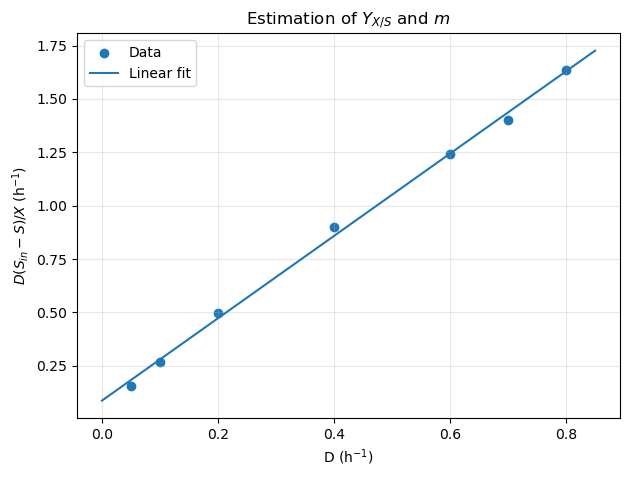

In [10]:
D = np.array([0.05, 0.10, 0.20, 0.40, 0.60, 0.70, 0.80, 0.84])
X = np.array([3.2, 3.7, 4.0, 4.4, 4.75, 4.9, 4.5, 0.5])
S = np.array([0.012, 0.028, 0.050, 0.100, 0.150, 0.176, 0.800, 9.000])

S_in = 10.0

# exclude washout point
mask = D <= 0.80
D_fit = D[mask]
X_fit = X[mask]
S_fit = S[mask]

# transformed variable
y = D_fit * (S_in - S_fit) / X_fit

# linear fit: y = aD + b
slope, intercept = np.polyfit(D_fit, y, 1)

Yxs = 1 / slope
m = intercept

print(f"slope = {slope:.4f}")
print(f"intercept = {intercept:.4f}")
print(f"Yxs = {Yxs:.4f} gX/gS")
print(f"m = {m:.4f} gS/(gX·h)")

# plot
D_line = np.linspace(0, 0.85, 200)
y_line = slope * D_line + intercept

plt.figure(figsize=(7,5))
plt.scatter(D_fit, y, label="Data")
plt.plot(D_line, y_line, label="Linear fit")
plt.xlabel("D (h$^{-1}$)")
plt.ylabel(r"$D(S_{in}-S)/X$ (h$^{-1}$)")
plt.title("Estimation of $Y_{X/S}$ and $m$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

| Parameter | Value | Units |
|-----------|-------|-------|
| $Y_{X/S}$ | 0.5185 | g biomass / g substrate |
| $m$ | 0.0872 | g substrate / g biomass / h |
 
The estimated yield coefficient $Y_{X/S} = 0.5185\ \mathrm{g_X/g_S}$ indicates that approximately 0.52 g of biomass are produced per gram of substrate consumed. This value is lower than 1, which is expected, as part of the substrate is not converted into biomass but is instead used for energy production and cellular functions. Next, the maintenance coefficient $m = 0.0872\ \mathrm{g_S\,g_X^{-1}\,h^{-1}}$ represents the amount of substrate consumed per unit biomass and time for non-growth-related processes. These include cellular maintenance activities such as ion transport, macromolecule turnover, and metabolic regulation. The positive value of $m$ is reflected by the non-zero y-intercept of the linear fit, indicating that even at very low growth rates, substrate is still consumed. This confirms the presence of maintenance metabolism in the system.

Overall, the results are physically consistent. In fact, the yield coefficient is within a reasonable range for microbial systems, and the maintenance term highlights that not all substrate contributes directly to biomass formation, especially at low dilution rates.

**Question c)**

Ignoring maintenance, the steady-state chemostat follows Monod kinetics:

$$
D=\mu=\mu_{\max}\frac{S}{K_s+S}
$$

**Maximum dilution rate**
The maximum dilution rate is reached at washout, when the reactor substrate concentration approaches the feed substrate concentration:

$$
S \to S_{in}
$$

Therefore,

$$
D_{\max}=\mu_{\max}\frac{S_{in}}{K_s+S_{in}}
$$

Using $\mu_{\max}=2.298\ \mathrm{h^{-1}}$, $K_s=0.548\ \mathrm{g\,L^{-1}}$, and $S_{in}=10\ \mathrm{g\,L^{-1}}$:

$$
D_{\max}=2.298\frac{10}{0.548+10}=2.179\ \mathrm{h^{-1}}
$$

**Optimal dilution rate**

The cell productivity is:

$$
P_X=D\cdot X
$$

Ignoring maintenance,

$$
X=Y_{X/S}(S_{in}-S)
$$

so maximizing productivity is equivalent to maximizing:

$$
D(S_{in}-S)
$$

From the Monod relation,

$$
D=\mu_{\max}\frac{S}{K_s+S}
$$

we solve for $S$:

$$
S=\frac{DK_s}{\mu_{\max}-D}
$$

Substituting into the productivity expression and maximizing with respect to $D$ gives:

$$
D_{\mathrm{opt}}=\mu_{\max}\left(1-\sqrt{\frac{K_s}{K_s+S_{in}}}\right)
$$

Numerically:

$$
D_{\mathrm{opt}}=2.298\left(1-\sqrt{\frac{0.548}{0.548+10}}\right)=1.774\ \mathrm{h^{-1}}
$$

Thus, the theoretical values are:

$$
D_{\max}=2.179\ \mathrm{h^{-1}}
$$

$$
D_{\mathrm{opt}}=1.774\ \mathrm{h^{-1}}
$$

As expected, $D_{\mathrm{opt}} < D_{\max}$, since the maximum biomass productivity is reached before washout.